# TS Multimavriate
* Inputs: 3 variables (Temp, Humidity, Pressure)
* Outputs: 3 future steps of Temperature (n_future)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler


In [19]:
# Create synthetic environmental data
np.random.seed(42)
time = np.arange(0, 500, 1)

temp = 20 + 5*np.sin(time*0.02)      # Temperature
hum  = 50 + 10*np.cos(time*0.015)    # Humidity
pres = 1013 + 3*np.sin(time*0.01)    # Pressure

data = np.stack([temp, hum, pres], axis=1)   # shape (500, 3)
print(data[:5])

[[  20.           60.         1013.        ]
 [  20.09999333   59.99887502 1013.0299995 ]
 [  20.19994667   59.99550034 1013.059996  ]
 [  20.29982003   59.98987671 1013.0899865 ]
 [  20.39957347   59.9820054  1013.119968  ]]


In [20]:
from sklearn.preprocessing import MinMaxScaler

# Normalize the data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
print(data_scaled[:5])

[[0.49999729 1.         0.49999937]
 [0.50999686 0.99994375 0.50499929]
 [0.51999242 0.99977501 0.50999872]
 [0.52998    0.99949383 0.51499714]
 [0.53995557 0.99910026 0.51999406]]


In [21]:
# input windows (look_back) and future output sequences (n_future)
def create_seq2seq_dataset(series, look_back=20, n_future=5):
    X, y = [], []
    for i in range(len(series) - look_back - n_future + 1): # added + 1 to include last elt
        X.append(series[i : i + look_back, :])              # all 3 features
        y.append(series[i + look_back : i + look_back + n_future, 0])  # predict Temperature only
    return np.array(X), np.array(y)


In [36]:
test_series = np.arange(36).reshape(12, 3) # 12 arrays with 3 variables each
print(test_series)
X, y = create_seq2seq_dataset(test_series, look_back=5, n_future=3)
print(f"---- X\n{X}")
print(f"---- y\n{y}")

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]
 [15 16 17]
 [18 19 20]
 [21 22 23]
 [24 25 26]
 [27 28 29]
 [30 31 32]
 [33 34 35]]
---- X
[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]
  [ 9 10 11]
  [12 13 14]]

 [[ 3  4  5]
  [ 6  7  8]
  [ 9 10 11]
  [12 13 14]
  [15 16 17]]

 [[ 6  7  8]
  [ 9 10 11]
  [12 13 14]
  [15 16 17]
  [18 19 20]]

 [[ 9 10 11]
  [12 13 14]
  [15 16 17]
  [18 19 20]
  [21 22 23]]

 [[12 13 14]
  [15 16 17]
  [18 19 20]
  [21 22 23]
  [24 25 26]]]
---- y
[[15 18 21]
 [18 21 24]
 [21 24 27]
 [24 27 30]
 [27 30 33]]


In [23]:
look_back = 20
n_future = 3

X, y = create_seq2seq_dataset(data_scaled, look_back, n_future)

In [24]:
X.shape, y.shape

((478, 20, 3), (478, 3))

In [25]:
#print(X[:5])

In [26]:
#print(y[:5])

In [27]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
y_train.shape, y_test.shape

((382, 3), (96, 3))

In [28]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(look_back, 3)),
    LSTM(32, return_sequences=False),
    Dense(32, activation='relu'),
    #Dense(16, activation='relu'),
    Dense(n_future)   # 5 future time steps
])

model.compile(optimizer='adam', loss='mse')
# model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=0
)


In [30]:
# Forecast on Test Data
pred_scaled = model.predict(X_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 


In [31]:
# Build a zero array to use inverse transform
def invert_temp(scaled_temp_seq):
    temp_full = np.zeros((len(scaled_temp_seq), 3))
    temp_full[:, 0] = scaled_temp_seq
    return scaler.inverse_transform(temp_full)[:, 0]

pred = np.array([invert_temp(p) for p in pred_scaled])
actual = np.array([invert_temp(t) for t in y_test])


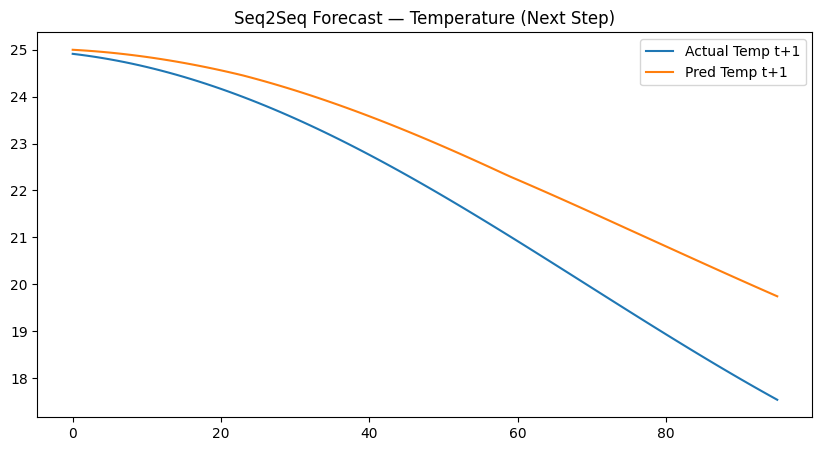

In [32]:
plt.figure(figsize=(10,5))
plt.plot(actual[:,0], label="Actual Temp t+1")
plt.plot(pred[:,0], label="Pred Temp t+1")
plt.legend()
plt.title("Seq2Seq Forecast — Temperature (Next Step)")
plt.show() # 500*0.2 = 100 test data


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE and RMSE using the flattened actual and predicted values
mae = mean_absolute_error(actual.flatten(), pred.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(), pred.flatten()))

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 1.2225
Root Mean Squared Error (RMSE): 1.4507


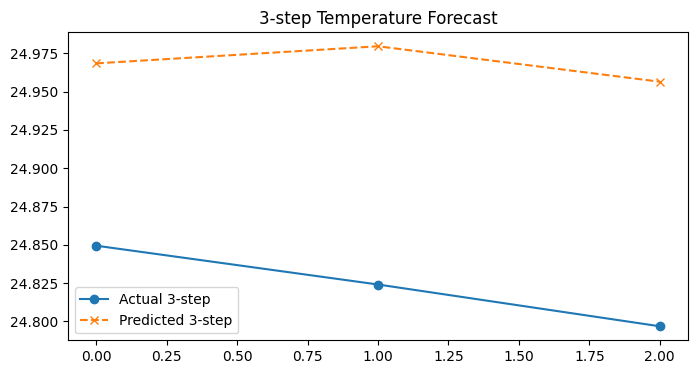

In [35]:
sample = 3 # one sample

plt.figure(figsize=(8,4))
plt.plot(actual[sample], 'o-', label=f'Actual {n_future}-step')
plt.plot(pred[sample], 'x--', label=f'Predicted {n_future}-step')
plt.title(f"{n_future}-step Temperature Forecast")
plt.legend()
plt.show()
